# **Importing Python Libraries**







In [1]:
#  IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
import tensorflow as tf
import joblib

In [2]:
sns.set(style="whitegrid")

In [3]:
df = pd.read_csv('../data/processed/retail_store_inventory_cleaned.csv')

# **Encoding Categorical Features**

In [4]:
#print all objects need encoding
print(df.select_dtypes(include='object').columns)

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'weather_condition', 'seasonality'],
      dtype='object')


In [5]:
print(df[['store_id', 'product_id', 'category' , 'seasonality', 'region', 'weather_condition' ]].head())

  store_id product_id     category seasonality region weather_condition
0     S001      P0001    Groceries      Winter  South             Snowy
1     S001      P0001         Toys      Autumn  South             Snowy
2     S001      P0001         Toys      Autumn  South             Snowy
3     S001      P0001    Furniture      Spring   East             Sunny
4     S001      P0001  Electronics      Winter  South            Cloudy


In [6]:
# 1. LABEL ENCODING
# للأعمدة الكبيرة High Cardinality

label_cols = [
    'store_id',
    'product_id'
]

label_encoders = {}

for col in label_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le
import joblib
joblib.dump(label_encoders, "../models/label_encoders.pkl")

# 2. ONE HOT ENCODING
# للأعمدة الصغيرة


onehot_cols = [
    'category',
    'region',
    'weather_condition',
    'seasonality'
]

df = pd.get_dummies(
    df,
    columns=onehot_cols,
    drop_first=True,
    dtype=int
)

joblib.dump(df.columns.tolist(), "../models/features.pkl")
# CHECK RESULT

print(df.head())

print(df.shape)

         date  store_id  product_id  inventory_level  units_sold  \
0  2022-03-02         0           0              216          93   
1  2022-03-03         0           0              304          36   
2  2022-03-04         0           0              338         284   
3  2022-03-05         0           0              496         282   
4  2022-03-06         0           0              463         192   

   units_ordered  price  discount  holiday/promotion  competitor_pricing  ...  \
0            120  58.52        15                  1               58.92  ...   
1             44  14.01         0                  1               12.87  ...   
2             43  33.06        15                  0               34.47  ...   
3            167  27.67        10                  0               28.65  ...   
4             54  62.37        10                  1               64.64  ...   

   category_Toys  region_North  region_South  region_West  \
0              0             0             

# **Showing New Columns**

In [7]:
print(df.columns)

Index(['date', 'store_id', 'product_id', 'inventory_level', 'units_sold',
       'units_ordered', 'price', 'discount', 'holiday/promotion',
       'competitor_pricing', 'year', 'month', 'weekday', 'weekofyear',
       'is_weekend', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7',
       'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_60', 'price_diff',
       'discount_effect', 'price_ratio', 'category_Electronics',
       'category_Furniture', 'category_Groceries', 'category_Toys',
       'region_North', 'region_South', 'region_West',
       'weather_condition_Rainy', 'weather_condition_Snowy',
       'weather_condition_Sunny', 'seasonality_Spring', 'seasonality_Summer',
       'seasonality_Winter'],
      dtype='object')


In [8]:
print(df[[
    'store_id',
    'product_id'
]].head())

print(df.filter(like='category').head())

print(df.filter(like='region').head())

print(df.filter(like='weather').head())

print(df.filter(like='seasonality').head())

   store_id  product_id
0         0           0
1         0           0
2         0           0
3         0           0
4         0           0
   category_Electronics  category_Furniture  category_Groceries  category_Toys
0                     0                   0                   1              0
1                     0                   0                   0              1
2                     0                   0                   0              1
3                     0                   1                   0              0
4                     1                   0                   0              0
   region_North  region_South  region_West
0             0             1            0
1             0             1            0
2             0             1            0
3             0             0            0
4             0             1            0
   weather_condition_Rainy  weather_condition_Snowy  weather_condition_Sunny
0                        0                     

# **Feature & Target**



In [9]:
TARGET = 'units_sold'

x = df.drop(columns=[
    'units_sold',
    'date'
])

y = df[TARGET]

In [10]:
# Remove Date (model doesn't understand datetime)
df = df.drop(columns=['date'])

# **Time Series Train Test Split**

In [11]:
split_index = int(len(df) * 0.8)

x_train = x.iloc[:split_index]

x_test = x.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

In [12]:
print("Train Shape:", x_train.shape)

print("Test Shape:", x_test.shape)

Train Shape: (53680, 37)
Test Shape: (13420, 37)


# **Model - XGBOOST - Train**

In [13]:
xgb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [14]:
xgb_model.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

# **Model - XGBOOST - Prediction**

In [15]:
xgb_pred = xgb_model.predict(x_test)

In [16]:
print(xgb_pred)

[107.852234 157.68452  218.44807  ... 126.473495  21.375824  51.802208]


# **Model - LIGHTGBM - Train**





In [17]:
lgb_model = LGBMRegressor(

    n_estimators=1000,

    learning_rate=0.03,

    num_leaves=64,

    max_depth=-1,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

lgb_model.fit(x_train,y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011621 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3884
[LightGBM] [Info] Number of data points in the train set: 53680, number of used features: 37
[LightGBM] [Info] Start training from score 136.119281


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.03
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# **Model - LIGHTGBM - Prediction**

In [18]:
lgb_pred= lgb_model.predict(x_test)
print(lgb_pred[:10])

[113.04699048 174.92737147 196.82220296 226.18418607  25.59183052
 154.73233508 146.59520326 167.13453384 171.33631987 126.86011755]


# **Model Evaluation**





In [19]:
def evaluate(y_true, y_pred, model_name):

    print(f"\n===== {model_name} =====")

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print("MAE :", mae)

    print("RMSE:", rmse)

    print("R2  :", r2)


evaluate(y_test, xgb_pred, "XGBoost")

evaluate(y_test, lgb_pred, "LightGBM")


===== XGBoost =====
MAE : 69.72342681884766
RMSE: 89.40664867964239
R2  : 0.3357241749763489

===== LightGBM =====
MAE : 69.59843457421142
RMSE: 89.28126934275784
R2  : 0.3375859445196864


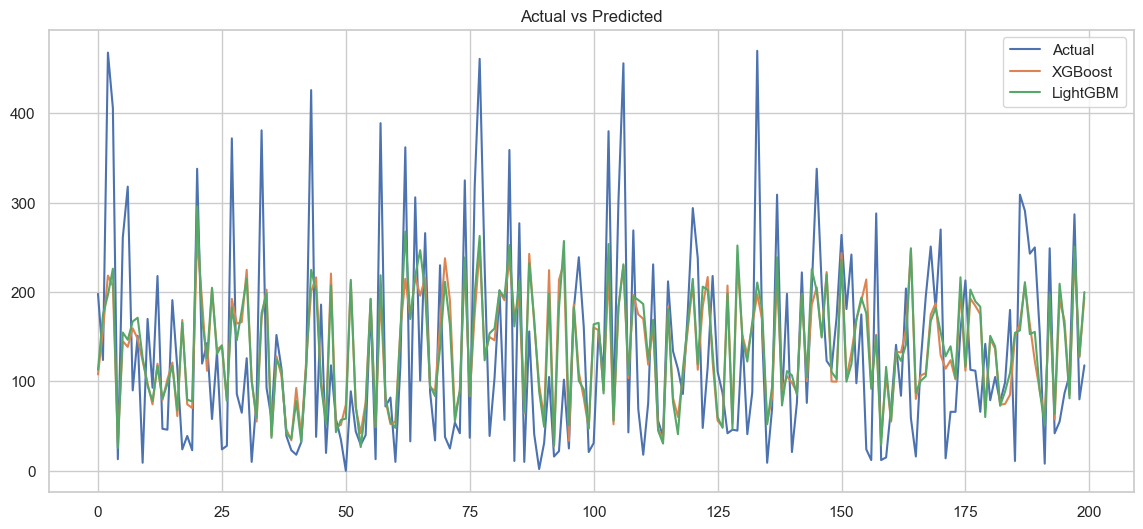

In [20]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    xgb_pred[:200],
    label='XGBoost'
)

plt.plot(
    lgb_pred[:200],
    label='LightGBM'
)

plt.legend()

plt.title("Actual vs Predicted")

plt.show()

# **Feature Importance**

**XGBoost**

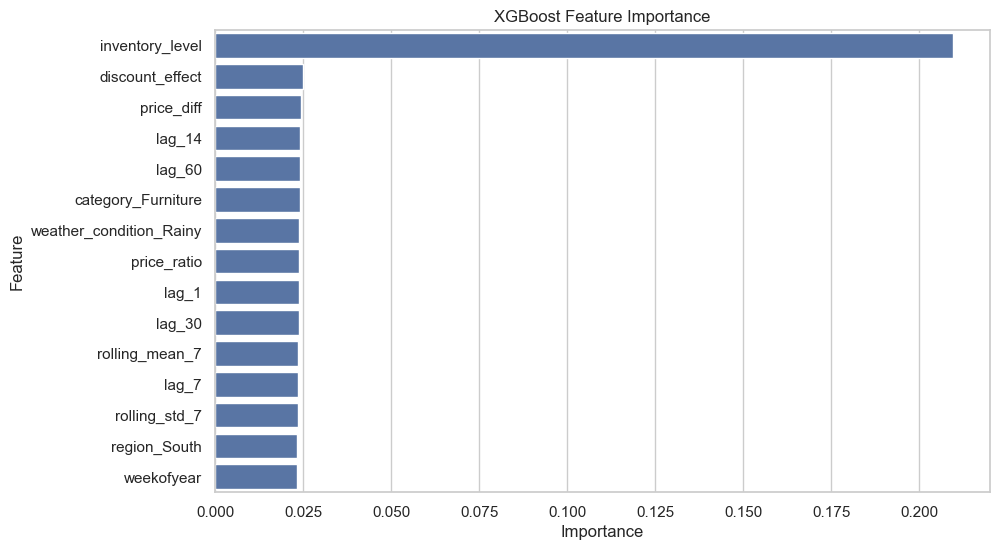

In [21]:
importance_xgb = pd.DataFrame({

    'Feature': x.columns,

    'Importance': xgb_model.feature_importances_
})

importance_xgb = importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(

    x='Importance',

    y='Feature',

    data=importance_xgb.head(15)
)

plt.title("XGBoost Feature Importance")

plt.show()

**LightGBM**

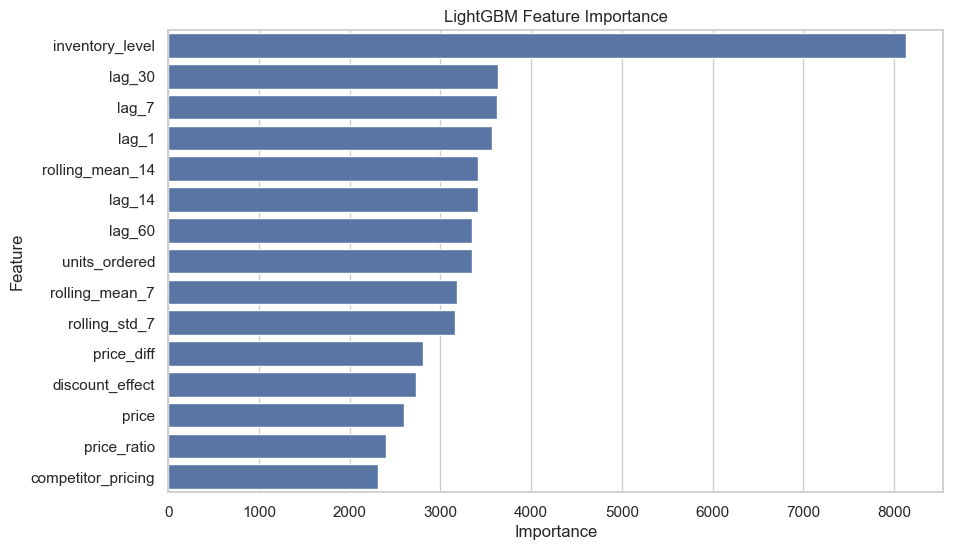

In [22]:
importance_lgb = pd.DataFrame({

    'Feature': x.columns,

    'Importance': lgb_model.feature_importances_
})

importance_lgb = importance_lgb.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(

    x='Importance',

    y='Feature',

    data=importance_lgb.head(15)
)

plt.title("LightGBM Feature Importance")

plt.show()

# **Actual vs Predicted**

# **Correlation Matrix**

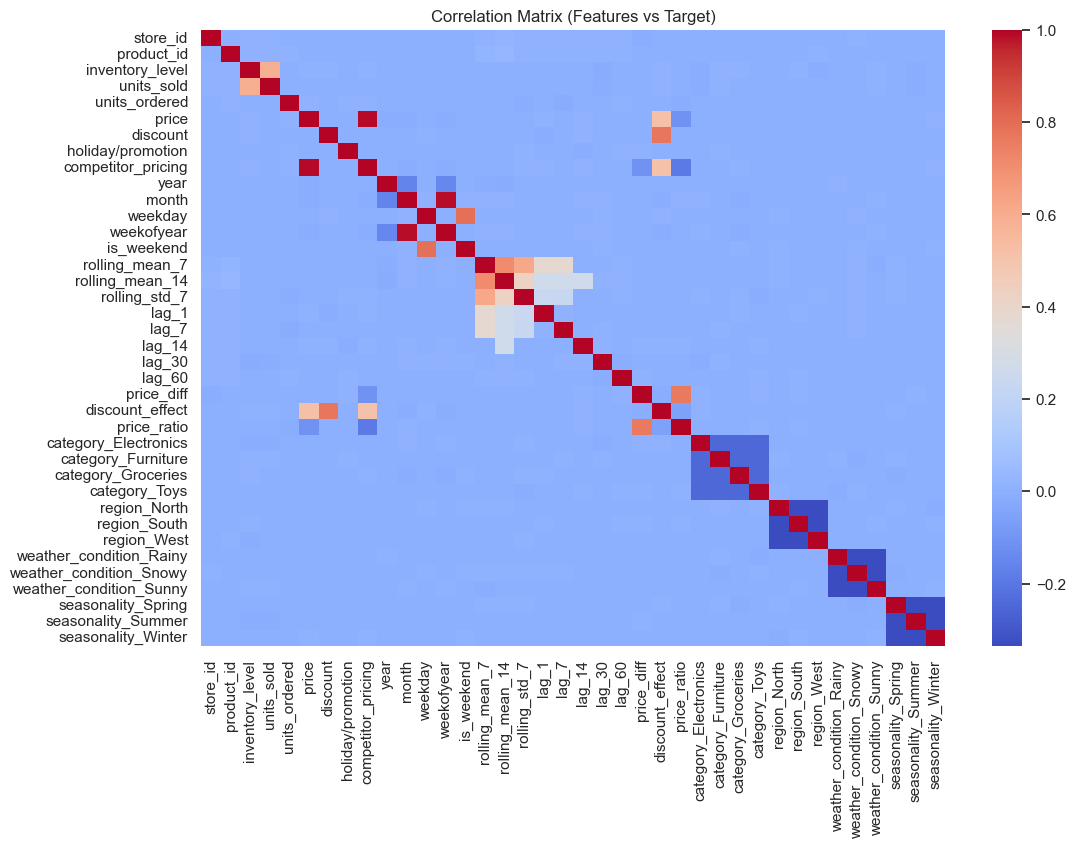

In [23]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Matrix (Features vs Target)")
plt.show()

# **Business Insights** - **Optimize Inventory**

**Data Preparation**

In [24]:
df_results = x_test.copy()

df_results['actual'] = y_test.values

df_results['predicted'] = lgb_pred

df_results['inventory_level'] = df.loc[x_test.index, 'inventory_level']

# **Stockout Risk**

In [25]:
df_results['stockout_risk'] = df_results['predicted'] > df_results['inventory_level']

df_results['stockout_risk'].value_counts()

stockout_risk
False    13419
True         1
Name: count, dtype: int64

# **Overstock Risk**

In [26]:
df_results['overstock_risk'] = df_results['inventory_level'] > (1.5 * df_results['predicted'])

df_results['overstock_risk'].value_counts()

overstock_risk
True     13335
False       85
Name: count, dtype: int64

# **Most Risky Products**

In [27]:
risk_products = df_results.groupby('product_id')[['stockout_risk','overstock_risk']].sum()

risk_products.sort_values(by='stockout_risk', ascending=False).head(10)

,stockout_risk,overstock_risk
product_id,,
19,1,664
0,0,664
2,0,667
1,0,667
3,0,667
4,0,666
6,0,667
5,0,665
8,0,670


# **Risky Stores**

In [28]:
df_results.groupby('store_id')['stockout_risk'].sum().sort_values(ascending=False).head(10)

store_id
4    1
Name: stockout_risk, dtype: int64

# **Model Saving**

In [29]:

import os

os.makedirs('../models', exist_ok=True)



In [30]:
joblib.dump(xgb_model, "../models/xgboost_model.pkl")
joblib.dump(lgb_model, "../models/lightgbm_model.pkl")

print("Models saved to local models directory successfully!")

Models saved to local models directory successfully!


In [32]:
df.head()

,store_id,product_id,inventory_level,units_sold,units_ordered,price,discount,holiday/promotion,competitor_pricing,year,...,category_Toys,region_North,region_South,region_West,weather_condition_Rainy,weather_condition_Snowy,weather_condition_Sunny,seasonality_Spring,seasonality_Summer,seasonality_Winter
0,0,0,216,93,120,58.52,15,1,58.92,2022,...,0,0,1,0,0,1,0,0,0,1
1,0,0,304,36,44,14.01,0,1,12.87,2022,...,1,0,1,0,0,1,0,0,0,0
2,0,0,338,284,43,33.06,15,0,34.47,2022,...,1,0,1,0,0,1,0,0,0,0
3,0,0,496,282,167,27.67,10,0,28.65,2022,...,0,0,0,0,0,0,1,1,0,0
4,0,0,463,192,54,62.37,10,1,64.64,2022,...,0,0,1,0,0,0,0,0,0,1


# **Model Loading**

In [31]:
#xgb_model = joblib.load("/content/drive/MyDrive/xgboost_model.pkl")
#lgb_model = joblib.load("/content/drive/MyDrive/lightgbm_model.pkl")